Title:

The developed machine learning models are designed to predict the species of a tree based on key leaf characteristics, including shape, size, and color. By learning patterns from these morphological features, the models can accurately classify tree species and support automated plant identification systems.

Logistic regression

importing libraries

In [393]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


Data Collection and Processing

In [394]:
# loading the csv data to a Pandas DataFrame
data = pd.read_csv('leaf dataset.csv')

Splitting the Features and Target

In [395]:
le = LabelEncoder()
data['Tree'] = le.fit_transform(data['Tree_Species'])

In [396]:
x=data.drop('Tree_Species',axis='columns')
n=x.drop('Tree',axis='columns')
m=data['Tree']

Splitting the Data into Training data & Test Data

In [397]:
n_train, n_test, m_train, m_test = train_test_split(n, m, test_size=0.2,random_state=42)

Model Training

Logistic Regression

In [398]:
model = LogisticRegression(random_state=42)

In [399]:
# training the LogisticRegression model with Training data
model.fit(n_train, m_train)

c:\Users\AB\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Model Evaluation

Accuracy Score

In [400]:
# accuracy on training data
n_train_prediction = model.predict(n_train)
training_data_accuracy = accuracy_score(n_train_prediction, m_train)

In [401]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.8611111111111112


In [402]:
# accuracy on test data
n_test_prediction = model.predict(n_test)
log_test_data_accuracy = accuracy_score(n_test_prediction,m_test)

In [403]:
print('Accuracy on Test data : ', log_test_data_accuracy)

Accuracy on Test data :  0.75


naive bayes

In [404]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [405]:
data = pd.read_csv("leaf dataset.csv")

In [406]:
le = LabelEncoder()
data['Tree'] = le.fit_transform(data['Tree_Species'])


In [407]:
x=data.drop('Tree_Species',axis='columns')
n=x.drop('Tree',axis='columns')
m=data['Tree']

In [408]:
n_train, n_test, m_train, m_test = train_test_split(n, m, test_size=0.3,random_state=42)

In [409]:
#Applying the Gaussian naivebayes
classifier = GaussianNB()
classifier.fit(n_train, m_train)

,priors,None
,var_smoothing,1e-09


In [410]:
n_train_prediction = classifier.predict(n_train)
training_data_accuracy = accuracy_score(n_train_prediction, m_train)

In [411]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.8571428571428571


In [412]:
n_test_prediction = classifier.predict(n_test)
nai_test_data_accuracy = accuracy_score(n_test_prediction,m_test)

In [413]:
print('Accuracy on Test data : ', nai_test_data_accuracy)

Accuracy on Test data :  0.7037037037037037


SVM

In [414]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import svm
from sklearn.metrics import accuracy_score

In [415]:
data = pd.read_csv('leaf dataset.csv')

In [416]:
le = LabelEncoder()
data['Tree'] = le.fit_transform(data['Tree_Species'])

In [417]:
n=data.drop('Tree_Species',axis='columns')
x=n.drop('Tree',axis='columns')
Y=data['Tree']


In [418]:
scaler = StandardScaler()
scaler.fit(x)
standardized_data = scaler.transform(x)

In [419]:
X = standardized_data


In [420]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42)

In [421]:
print(X.shape, X_train.shape, X_test.shape)

(180, 6) (144, 6) (36, 6)


In [422]:
classifier = svm.SVC(kernel='linear')
classifier.fit(X_train, Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [423]:
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [424]:
print(training_data_accuracy)

0.8819444444444444


In [425]:
X_test_prediction = classifier.predict(X_test)
svm_test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [426]:
print(svm_test_data_accuracy)

0.75


Random forest


In [427]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix


In [428]:
data = pd.read_csv('leaf dataset.csv')

In [429]:
le = LabelEncoder()
data['Tree'] = le.fit_transform(data['Tree_Species'])

In [430]:
n=data.drop('Tree_Species',axis='columns')
x=n.drop('Tree',axis='columns')
y=data['Tree']

In [431]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=42)

In [432]:
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [433]:
x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)

In [434]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  1.0


In [435]:
x_test_prediction = model.predict(x_test)
random_test_data_accuracy = accuracy_score(x_test_prediction,y_test)


In [436]:
print('Accuracy on Test data : ', random_test_data_accuracy)

Accuracy on Test data :  0.7407407407407407


Decision tree

In [437]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [438]:
data = pd.read_csv('leaf dataset.csv')

In [439]:
le = LabelEncoder()
data['Tree'] = le.fit_transform(data['Tree_Species'])

In [440]:
n=data.drop('Tree_Species',axis='columns')
x=n.drop('Tree',axis='columns')
y=data['Tree']

In [441]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=42)

In [442]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [443]:
# accuracy on training data
x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction, y_train)

In [444]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  1.0


In [445]:
x_test_prediction = model.predict(x_test)
dec_test_data_accuracy = accuracy_score(x_test_prediction,y_test)

In [446]:
print('Accuracy on Test data : ', dec_test_data_accuracy)

Accuracy on Test data :  0.7407407407407407


Comparison bar chart

In [447]:
import matplotlib.pyplot as plt

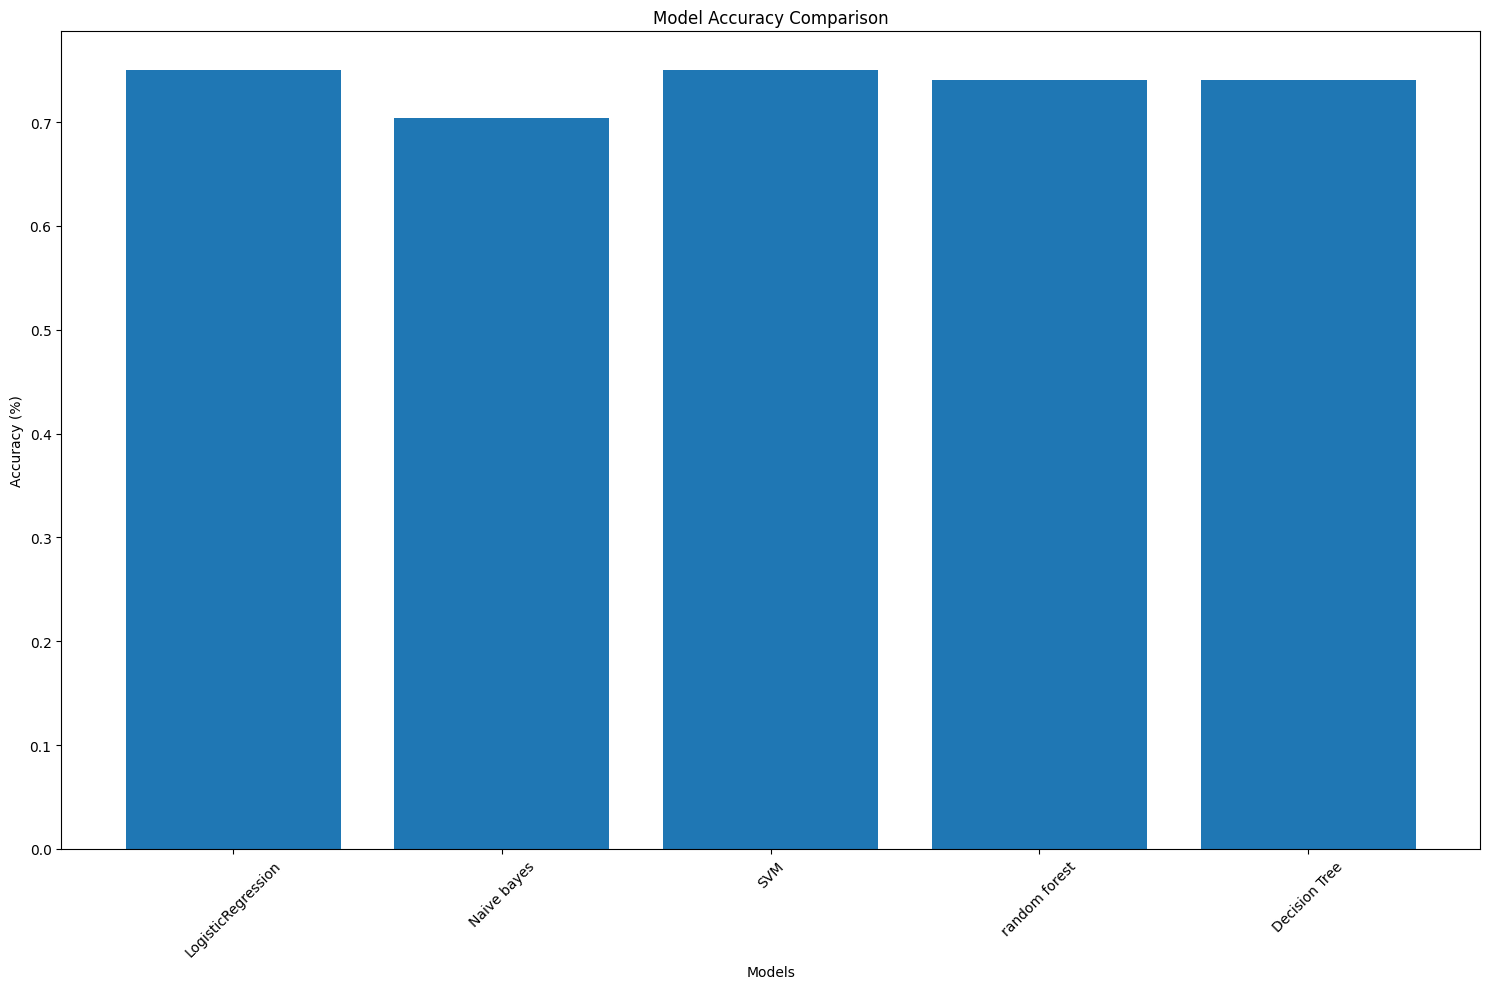

In [448]:
models = [ 'LogisticRegression','Naive bayes', 'SVM','random forest', 'Decision Tree']
accuracy = [log_test_data_accuracy,nai_test_data_accuracy,svm_test_data_accuracy,
            random_test_data_accuracy,dec_test_data_accuracy]
# Create bar chart
plt.figure(figsize=(15,10))
plt.bar(models, accuracy)
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()